# EDA — Dataset Aumentado BioCatch (~1M sesiones)

**Iniciativa Anti-Vishing:** Análisis Exploratorio del Dataset Sintético Aumentado

## Objetivo

Análisis exploratorio del dataset aumentado sintéticamente a partir del dataset original analizado en `1_EDA.ipynb`. El análisis busca:

1. **Validar la integridad del dataset aumentado** — nulos, tipos, rangos, duplicados esperados
2. **Caracterizar el cambio en balance de clases** respecto al dataset original
3. **Confirmar que las señales discriminativas se preservaron** después de la aumentación
4. **Analizar las features nuevas** (`errors_per_minute`, `interactions_per_s`, `hesitation_composite`, sensores inerciales)
5. **Comparar distribuciones** del dataset aumentado vs el dataset original (KS test)
6. **Generar recomendaciones** para la estrategia de modelado con datos aumentados

**Dataset:** `data_augmentation/biocatch_augmented_1M.parquet` — ~1M sesiones, 54 features

**Referencia:** `raw_data/dataset_sintetico_biocatch_vishing_overlap.csv` — 50K sesiones originales

## 1. Setup y Carga de Datos

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import mannwhitneyu, chi2_contingency, pointbiserialr, ks_2samp
from matplotlib.patches import Patch
import warnings
warnings.filterwarnings('ignore')

plt.rcParams.update({
    'figure.figsize': (14, 6),
    'font.size': 11,
    'axes.titlesize': 14,
    'axes.labelsize': 12,
    'figure.dpi': 100,
    'axes.spines.top': False,
    'axes.spines.right': False,
})

COLORS = {'legit': '#2ecc71', 'vishing': '#e74c3c', 'neutral': '#3498db', 'aug': '#9b59b6'}
LABEL_MAP = {0: 'Legitima', 1: 'Vishing'}

print('Librerias cargadas')

Librerias cargadas


In [2]:
# Cargar dataset aumentado
df = pd.read_parquet('data_augmentation/biocatch_augmented_1M.parquet')

# session_timestamp viene como object en el parquet
df['session_timestamp'] = pd.to_datetime(df['session_timestamp'])

df_legit = df[df['is_vishing'] == 0]
df_vishing = df[df['is_vishing'] == 1]
imbalance = len(df_legit) // len(df_vishing)

print(f'Dataset aumentado: {df.shape[0]:,} filas x {df.shape[1]} columnas')
print(f'Sesiones legitimas: {len(df_legit):,} ({len(df_legit)/len(df)*100:.2f}%)')
print(f'Sesiones vishing:   {len(df_vishing):,} ({len(df_vishing)/len(df)*100:.2f}%)')
print(f'Imbalance ratio: 1:{imbalance}')
print()
print('Comparacion con dataset original:')
print(f'  Original:  50,000 filas | 95.0% legit | 5.0% vishing | ratio 1:19')
print(f'  Aumentado: {df.shape[0]:,} filas | {len(df_legit)/len(df)*100:.1f}% legit | {len(df_vishing)/len(df)*100:.1f}% vishing | ratio 1:{imbalance}')

Dataset aumentado: 1,001,940 filas x 54 columnas
Sesiones legitimas: 991,440 (98.95%)
Sesiones vishing:   10,500 (1.05%)
Imbalance ratio: 1:94

Comparacion con dataset original:
  Original:  50,000 filas | 95.0% legit | 5.0% vishing | ratio 1:19
  Aumentado: 1,001,940 filas | 99.0% legit | 1.0% vishing | ratio 1:94


## 2. Validación de Calidad del Dataset Aumentado

Los `session_id` duplicados son **esperados** — la aumentación genera sesiones sintéticas derivadas de sesiones originales que comparten el mismo ID base.

In [3]:
# 2.1 Tipos, nulos, duplicados
print('='*60)
print('TIPOS DE DATOS')
print('='*60)
for dtype, count in df.dtypes.value_counts().items():
    print(f'  {dtype}: {count} columnas')

print()
print('VALORES NULOS')
null_counts = df.isnull().sum()
if null_counts.sum() == 0:
    print('  Cero valores nulos')
else:
    print(null_counts[null_counts > 0])

print()
print('DUPLICADOS')
print(f'  Session IDs duplicados: {df["session_id"].duplicated().sum():,} (esperado en datos aumentados)')
print(f'  Filas completamente duplicadas: {df.duplicated().sum():,}')

print()
print('CLIENTES Y SESIONES')
print(f'  Customers unicos: {df["customer_id"].nunique():,}')
spc = df.groupby('customer_id').size()
print(f'  Sesiones/customer (promedio): {spc.mean():.1f}')
print(f'  Rango temporal: {df["session_timestamp"].min()} -> {df["session_timestamp"].max()}')

TIPOS DE DATOS
  float32: 27 columnas
  int32: 21 columnas
  object: 1 columnas
  category: 1 columnas
  category: 1 columnas
  datetime64[ns]: 1 columnas
  category: 1 columnas
  category: 1 columnas

VALORES NULOS
  Cero valores nulos

DUPLICADOS
  Session IDs duplicados: 74,099 (esperado en datos aumentados)
  Filas completamente duplicadas: 56,674

CLIENTES Y SESIONES
  Customers unicos: 19,765
  Sesiones/customer (promedio): 50.7
  Rango temporal: 2024-06-01 00:09:41 -> 2025-05-31 23:59:37


In [4]:
# 2.2 Columnas presentes vs dataset original
base_cols = {
    'session_id', 'customer_id', 'session_timestamp', 'device_type', 'os_type',
    'app_version', 'avg_keyhold_ms', 'avg_interkey_latency_ms', 'typing_speed_cps',
    'keystroke_variability', 'segmented_typing_ratio', 'avg_touch_pressure',
    'swipe_speed_px_s', 'swipe_directional_variance', 'scroll_speed_avg',
    'device_tilt_angle_mean', 'phone_motion_events', 'hesitation_count',
    'avg_hesitation_duration_s', 'max_hesitation_duration_s', 'dead_time_periods',
    'total_dead_time_s', 'dead_time_ratio', 'screens_visited', 'unusual_screen_visits',
    'navigation_back_count', 'screen_transition_time_avg_s', 'input_error_count',
    'input_correction_count', 'amount_field_corrections', 'beneficiary_field_corrections',
    'copy_paste_events', 'data_familiarity_score', 'doodling_events', 'session_duration_s',
    'hour_of_day', 'is_atypical_hour', 'phone_call_active', 'call_overlap_duration_s',
    'remote_access_tool_detected', 'suspicious_app_detected', 'transaction_attempted',
    'transaction_amount_cop', 'is_new_beneficiary', 'time_to_transaction_s', 'is_vishing'
}
orig_only = {
    'biocatch_risk_score', 'biocatch_genuine_score', 'biocatch_ato_indicator',
    'biocatch_social_eng_indicator', 'biocatch_bot_indicator', 'claim_category', 'days_to_claim'
}
aug_only = set(df.columns) - base_cols

print('COMPARACION DE COLUMNAS vs DATASET ORIGINAL')
print(f'  Solo en aumentado ({len(aug_only)}): {sorted(aug_only)}')
print(f'  Solo en original  ({len(orig_only)}): {sorted(orig_only)}')

COMPARACION DE COLUMNAS vs DATASET ORIGINAL
  Solo en aumentado (8): ['accelerometer_jerk_mean', 'avg_touch_size_px', 'device_tilt_variability', 'errors_per_minute', 'gyro_rotation_rate_mean', 'hesitation_composite', 'interactions_per_s', 'unique_screens_visited']
  Solo en original  (7): ['biocatch_ato_indicator', 'biocatch_bot_indicator', 'biocatch_genuine_score', 'biocatch_risk_score', 'biocatch_social_eng_indicator', 'claim_category', 'days_to_claim']


In [5]:
# 2.3 Validacion de rangos
range_checks = {
    'avg_touch_pressure': (0, 1), 'segmented_typing_ratio': (0, 1),
    'dead_time_ratio': (0, 1), 'data_familiarity_score': (0, 1),
    'keystroke_variability': (0, 1), 'hour_of_day': (0, 23),
    'device_tilt_angle_mean': (0, 90), 'is_vishing': (0, 1),
    'phone_call_active': (0, 1), 'errors_per_minute': (0, None), 'interactions_per_s': (0, None),
}

print('VALIDACION DE RANGOS')
all_ok = True
for col, (lo, hi) in range_checks.items():
    actual_min, actual_max = float(df[col].min()), float(df[col].max())
    ok = actual_min >= lo and (hi is None or actual_max <= hi)
    status = 'OK  ' if ok else 'FAIL'
    if not ok:
        all_ok = False
    print(f'  [{status}] {col}: [{actual_min:.3f}, {actual_max:.3f}]')
if all_ok:
    print('  Todos los rangos validos')

VALIDACION DE RANGOS
  [OK  ] avg_touch_pressure: [0.097, 0.912]
  [OK  ] segmented_typing_ratio: [0.000, 0.753]
  [OK  ] dead_time_ratio: [0.000, 0.489]
  [OK  ] data_familiarity_score: [0.043, 1.000]
  [OK  ] keystroke_variability: [0.010, 0.658]
  [OK  ] hour_of_day: [0.000, 23.000]
  [OK  ] device_tilt_angle_mean: [4.100, 85.944]
  [OK  ] is_vishing: [0.000, 1.000]
  [OK  ] phone_call_active: [0.000, 1.000]
  [OK  ] errors_per_minute: [0.000, 8.717]
  [OK  ] interactions_per_s: [1.400, 2.400]
  Todos los rangos validos


In [6]:
# 2.4 Estadisticas descriptivas
numeric_cols = [c for c in df.select_dtypes(include=[np.number]).columns if c != 'is_vishing']

desc = df[numeric_cols].describe().T
desc['skew'] = df[numeric_cols].skew()
desc['kurtosis'] = df[numeric_cols].kurtosis()
print(f'Estadisticas de {len(numeric_cols)} features numericas:')
desc[['count','mean','std','min','25%','50%','75%','max','skew','kurtosis']].round(3)

Estadisticas de 47 features numericas:


,count,mean,std,min,25%,50%,75%,max,skew,kurtosis
avg_keyhold_ms,1001940.0,88.151,20.705,21.500,76.659,91.039,101.227,1.896000e+02,-0.440,0.409
avg_interkey_latency_ms,1001940.0,171.273,44.995,30.000,139.188,169.313,194.892,4.146000e+02,0.552,0.529
typing_speed_cps,1001940.0,4.407,1.149,0.500,3.675,4.411,5.082,1.007000e+01,0.152,0.055
keystroke_variability,1001940.0,0.242,0.080,0.010,0.182,0.230,0.290,6.580000e-01,0.733,0.431
segmented_typing_ratio,1001940.0,0.197,0.107,0.000,0.123,0.169,0.249,7.530000e-01,1.117,1.073
avg_touch_pressure,1001940.0,0.524,0.090,0.097,0.466,0.506,0.575,9.120000e-01,0.643,0.946
avg_touch_size_px,1001940.0,44.640,7.880,11.600,39.053,43.461,49.575,7.570000e+01,0.493,0.286
swipe_speed_px_s,1001940.0,732.588,148.974,113.300,628.543,722.297,835.381,1.415500e+03,0.278,0.217
swipe_directional_variance,1001940.0,0.173,0.062,0.000,0.126,0.165,0.207,5.080000e-01,0.812,0.663
scroll_speed_avg,1001940.0,536.808,121.632,66.799,445.804,531.802,611.761,1.067802e+03,0.251,-0.224


## 3. Distribución del Target y Variables Categóricas

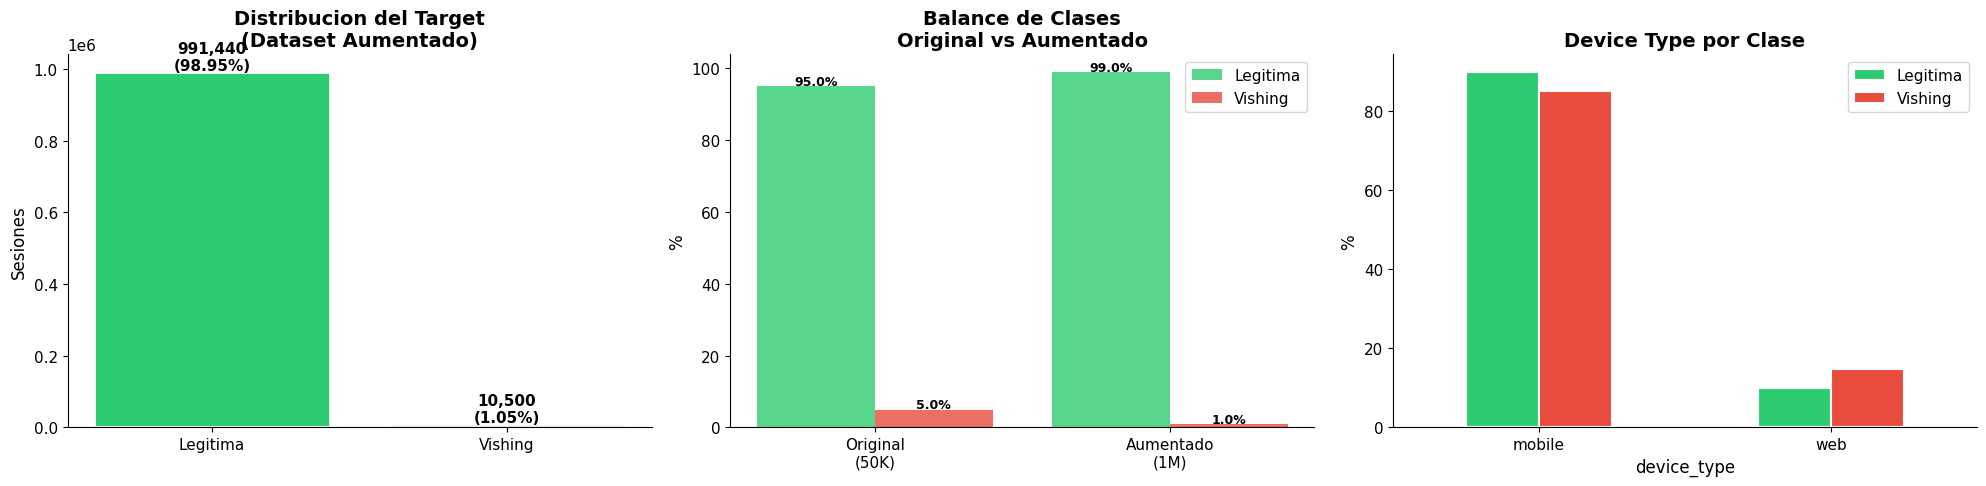

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(20, 5))

# 3.1 Target
counts = df['is_vishing'].value_counts().sort_index()
bars = axes[0].bar(['Legitima', 'Vishing'], counts.values,
                    color=[COLORS['legit'], COLORS['vishing']], edgecolor='white', linewidth=2)
for bar, val in zip(bars, counts.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5000,
                 f'{val:,}\n({val/len(df)*100:.2f}%)', ha='center', fontweight='bold')
axes[0].set_title('Distribucion del Target\n(Dataset Aumentado)', fontweight='bold')
axes[0].set_ylabel('Sesiones')

# 3.2 Comparacion balances
aug_pcts = [len(df_legit)/len(df)*100, len(df_vishing)/len(df)*100]
orig_pcts = [95.0, 5.0]
x = np.arange(2)
b1 = axes[1].bar(x - 0.2, [orig_pcts[0], aug_pcts[0]], 0.4, label='Legitima',
                  color=COLORS['legit'], alpha=0.8)
b2 = axes[1].bar(x + 0.2, [orig_pcts[1], aug_pcts[1]], 0.4, label='Vishing',
                  color=COLORS['vishing'], alpha=0.8)
axes[1].set_xticks(x)
axes[1].set_xticklabels(['Original\n(50K)', 'Aumentado\n(1M)'])
axes[1].set_title('Balance de Clases\nOriginal vs Aumentado', fontweight='bold')
axes[1].set_ylabel('%')
axes[1].legend()
for rect in list(b1) + list(b2):
    axes[1].text(rect.get_x() + rect.get_width()/2, rect.get_height() + 0.3,
                 f'{rect.get_height():.1f}%', ha='center', fontsize=9, fontweight='bold')

# 3.3 Device type
ct = pd.crosstab(df['device_type'], df['is_vishing'], normalize='columns') * 100
ct.plot(kind='bar', ax=axes[2], color=[COLORS['legit'], COLORS['vishing']],
        edgecolor='white', linewidth=1.5)
axes[2].set_title('Device Type por Clase', fontweight='bold')
axes[2].set_ylabel('%')
axes[2].set_xticklabels(axes[2].get_xticklabels(), rotation=0)
axes[2].legend(['Legitima', 'Vishing'])

plt.tight_layout()
plt.show()

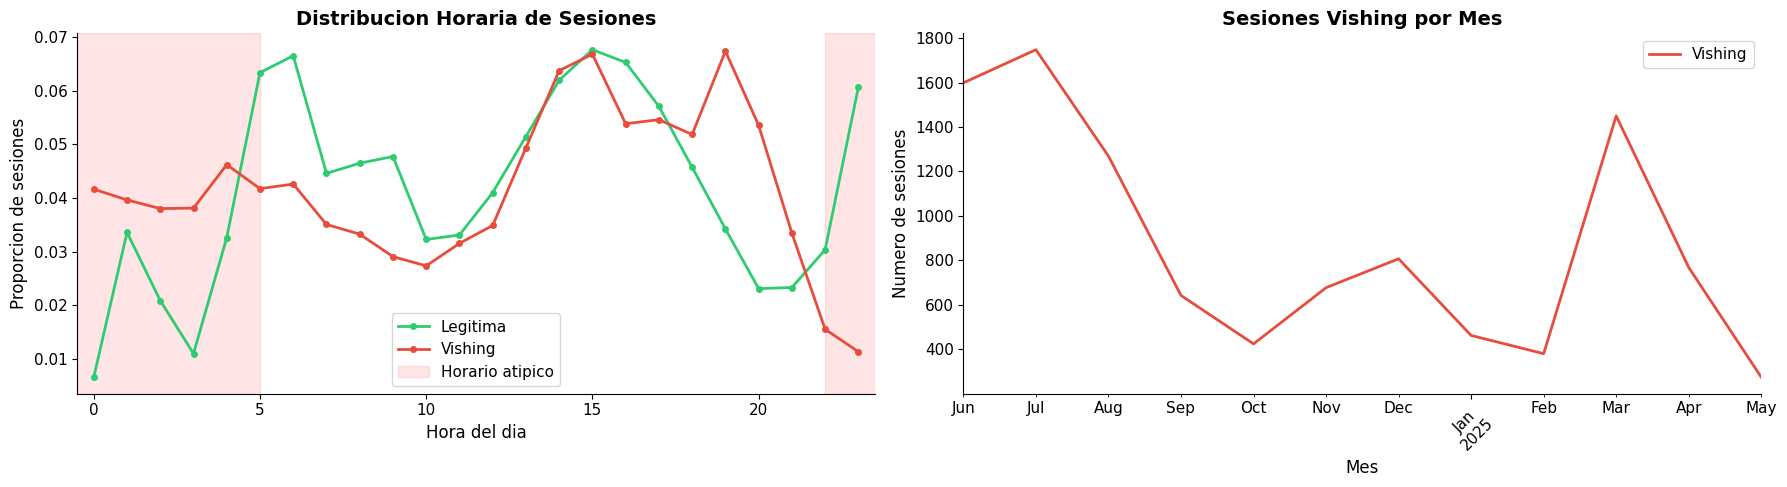

In [8]:
# 3.4 Distribucion temporal
fig, axes = plt.subplots(1, 2, figsize=(18, 5))

for label, subset, color in [(0, df_legit, COLORS['legit']), (1, df_vishing, COLORS['vishing'])]:
    hour_dist = subset['hour_of_day'].value_counts().sort_index()
    hour_dist = hour_dist / hour_dist.sum()
    axes[0].plot(hour_dist.index, hour_dist.values, '-o', color=color,
                 label=LABEL_MAP[label], linewidth=2, markersize=4)
axes[0].axvspan(22, 23.5, alpha=0.1, color='red', label='Horario atipico')
axes[0].axvspan(-0.5, 5, alpha=0.1, color='red')
axes[0].set_title('Distribucion Horaria de Sesiones', fontweight='bold')
axes[0].set_xlabel('Hora del dia')
axes[0].set_ylabel('Proporcion de sesiones')
axes[0].legend()
axes[0].set_xlim(-0.5, 23.5)

df['month'] = df['session_timestamp'].dt.to_period('M')
monthly = df.groupby(['month', 'is_vishing']).size().unstack(fill_value=0)
if 1 in monthly.columns:
    monthly[1].plot(ax=axes[1], color=COLORS['vishing'], linewidth=2, label='Vishing')
axes[1].set_title('Sesiones Vishing por Mes', fontweight='bold')
axes[1].set_xlabel('Mes')
axes[1].set_ylabel('Numero de sesiones')
axes[1].tick_params(axis='x', rotation=45)
axes[1].legend()
df.drop(columns='month', inplace=True)

plt.tight_layout()
plt.show()

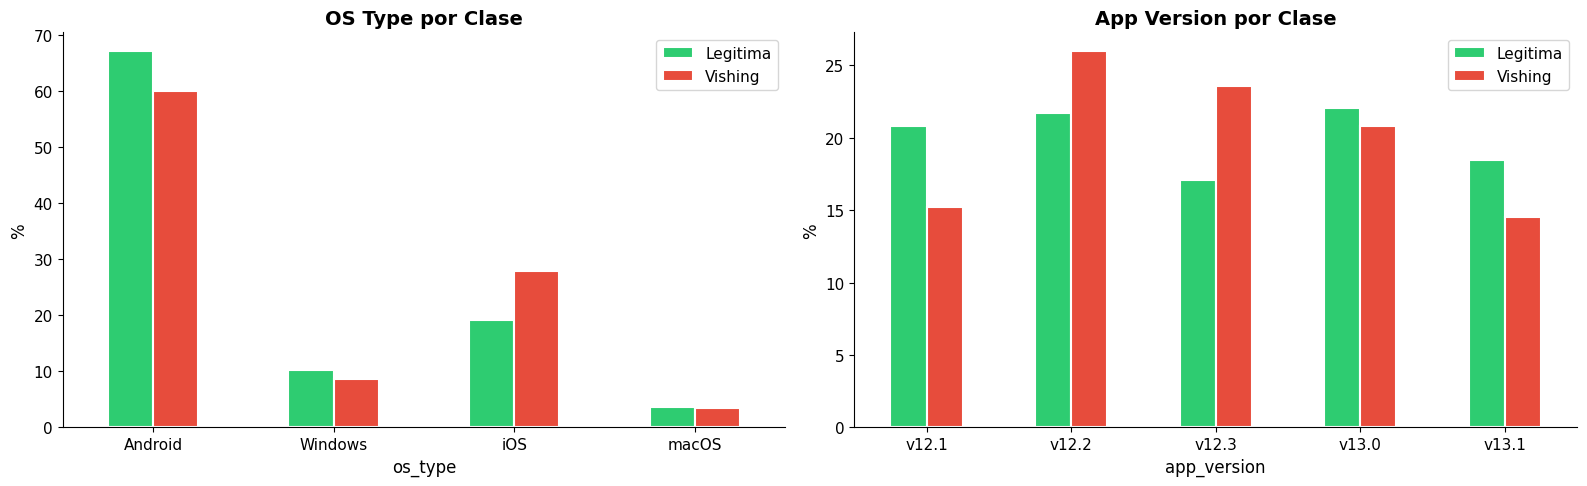

In [9]:
# 3.5 OS type y App version
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
for ax, col, title in [
    (axes[0], 'os_type', 'OS Type por Clase'),
    (axes[1], 'app_version', 'App Version por Clase')
]:
    ct = pd.crosstab(df[col], df['is_vishing'], normalize='columns') * 100
    ct.plot(kind='bar', ax=ax, color=[COLORS['legit'], COLORS['vishing']],
            edgecolor='white', linewidth=1.5)
    ax.set_title(title, fontweight='bold')
    ax.set_ylabel('%')
    ax.set_xticklabels(ax.get_xticklabels(), rotation=0)
    ax.legend(['Legitima', 'Vishing'])
plt.tight_layout()
plt.show()

## 4. Análisis Univariado — Distribución de Features por Clase

Con 1M sesiones el ruido de estimación es mínimo. Se usa subsample de 50K sesiones legítimas para visualización.

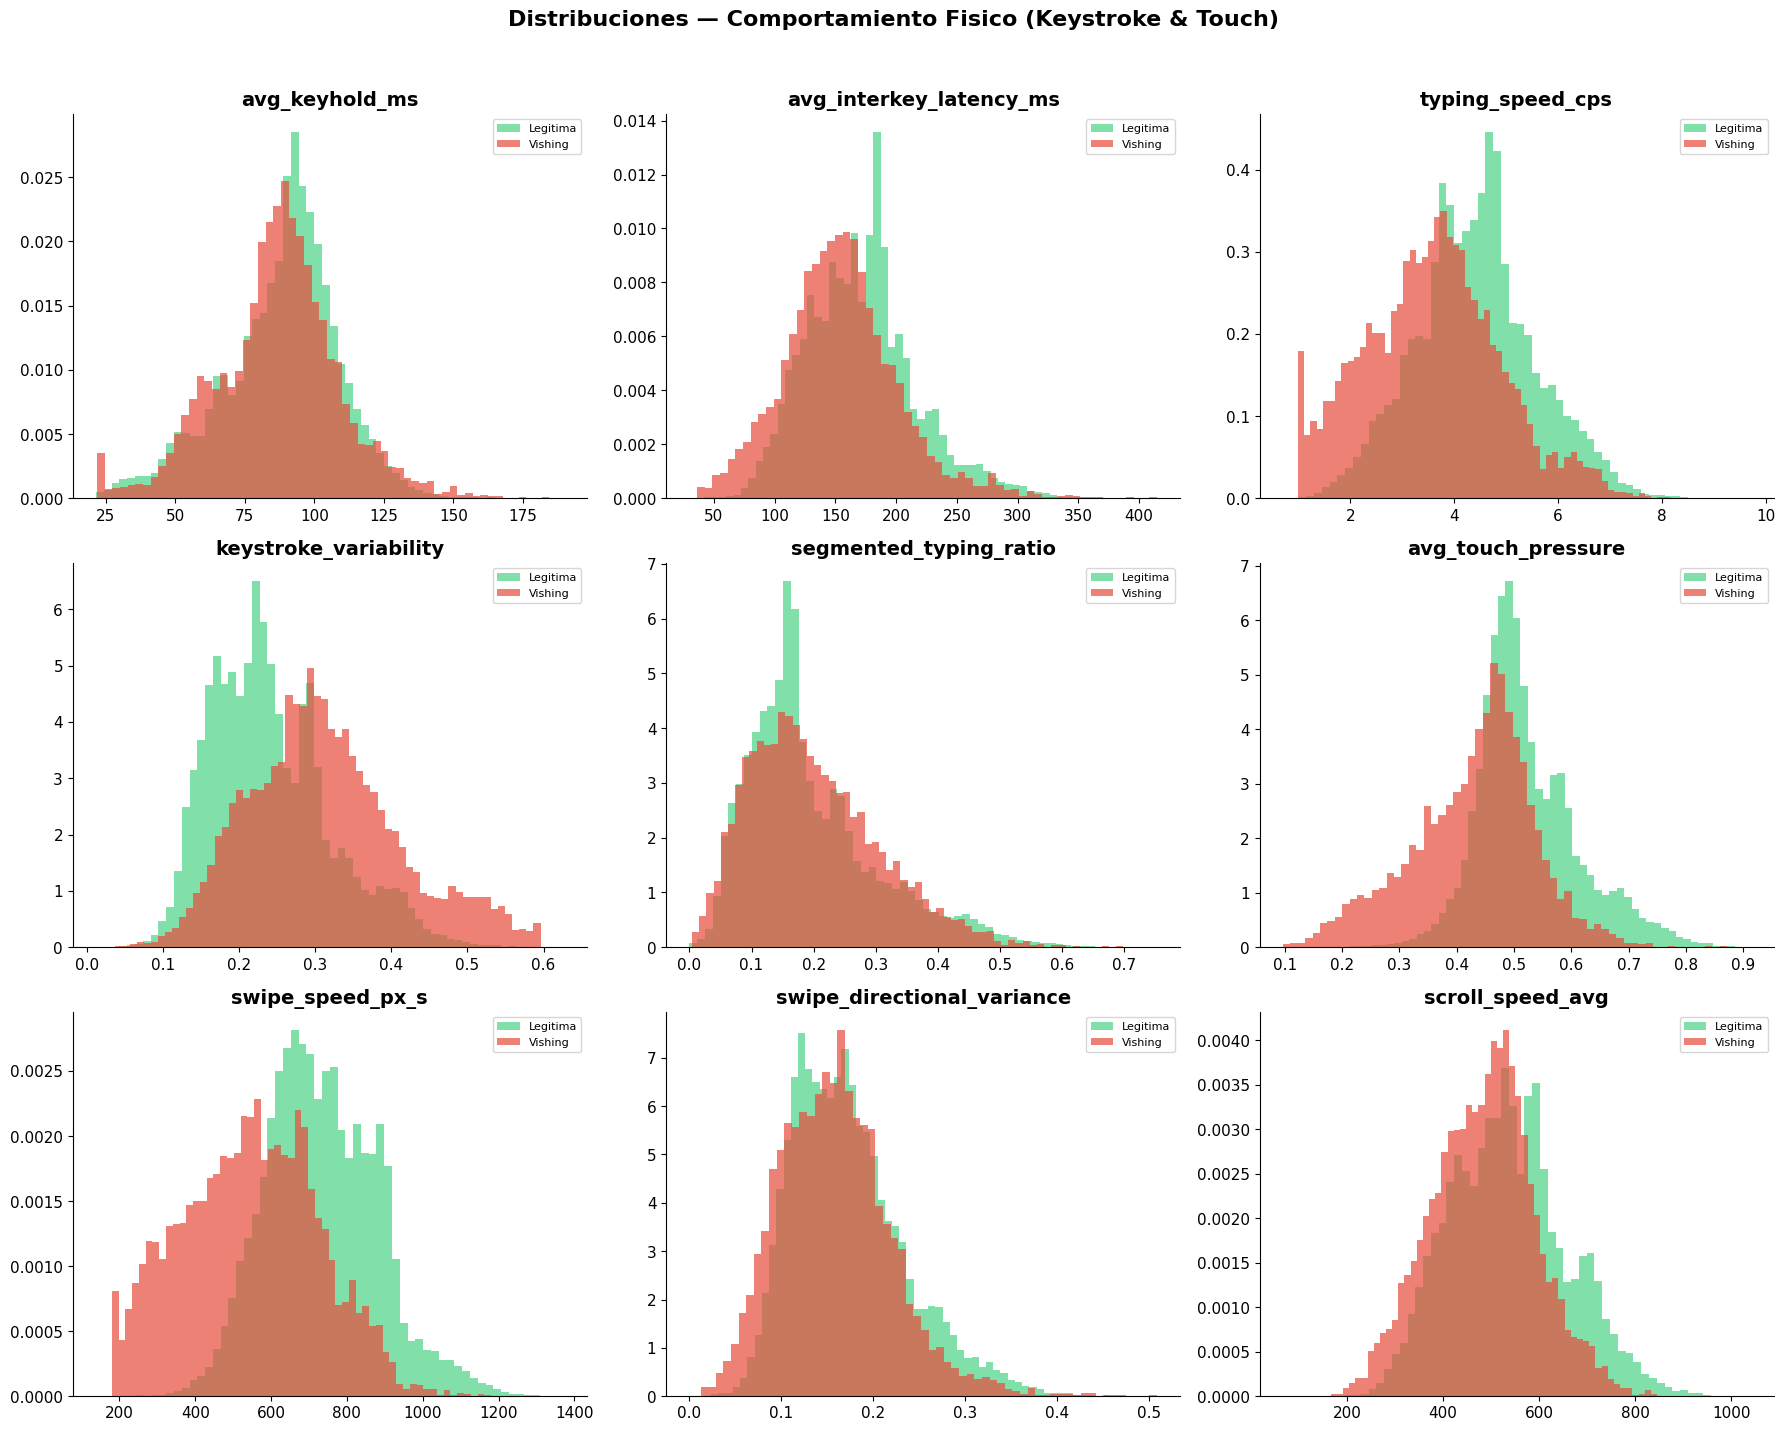

In [10]:
# 4.1 Comportamiento fisico — keystroke & touch
physical_features = [
    'avg_keyhold_ms', 'avg_interkey_latency_ms', 'typing_speed_cps',
    'keystroke_variability', 'segmented_typing_ratio', 'avg_touch_pressure',
    'swipe_speed_px_s', 'swipe_directional_variance', 'scroll_speed_avg'
]

fig, axes = plt.subplots(3, 3, figsize=(18, 14))
axes = axes.ravel()
for i, feat in enumerate(physical_features):
    ax = axes[i]
    ax.hist(df_legit[feat].sample(50000, random_state=42), bins=60, alpha=0.6,
            color=COLORS['legit'], label='Legitima', density=True, edgecolor='none')
    ax.hist(df_vishing[feat], bins=60, alpha=0.7, color=COLORS['vishing'],
            label='Vishing', density=True, edgecolor='none')
    ax.set_title(feat, fontweight='bold')
    ax.legend(fontsize=8)
fig.suptitle('Distribuciones — Comportamiento Fisico (Keystroke & Touch)',
             fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

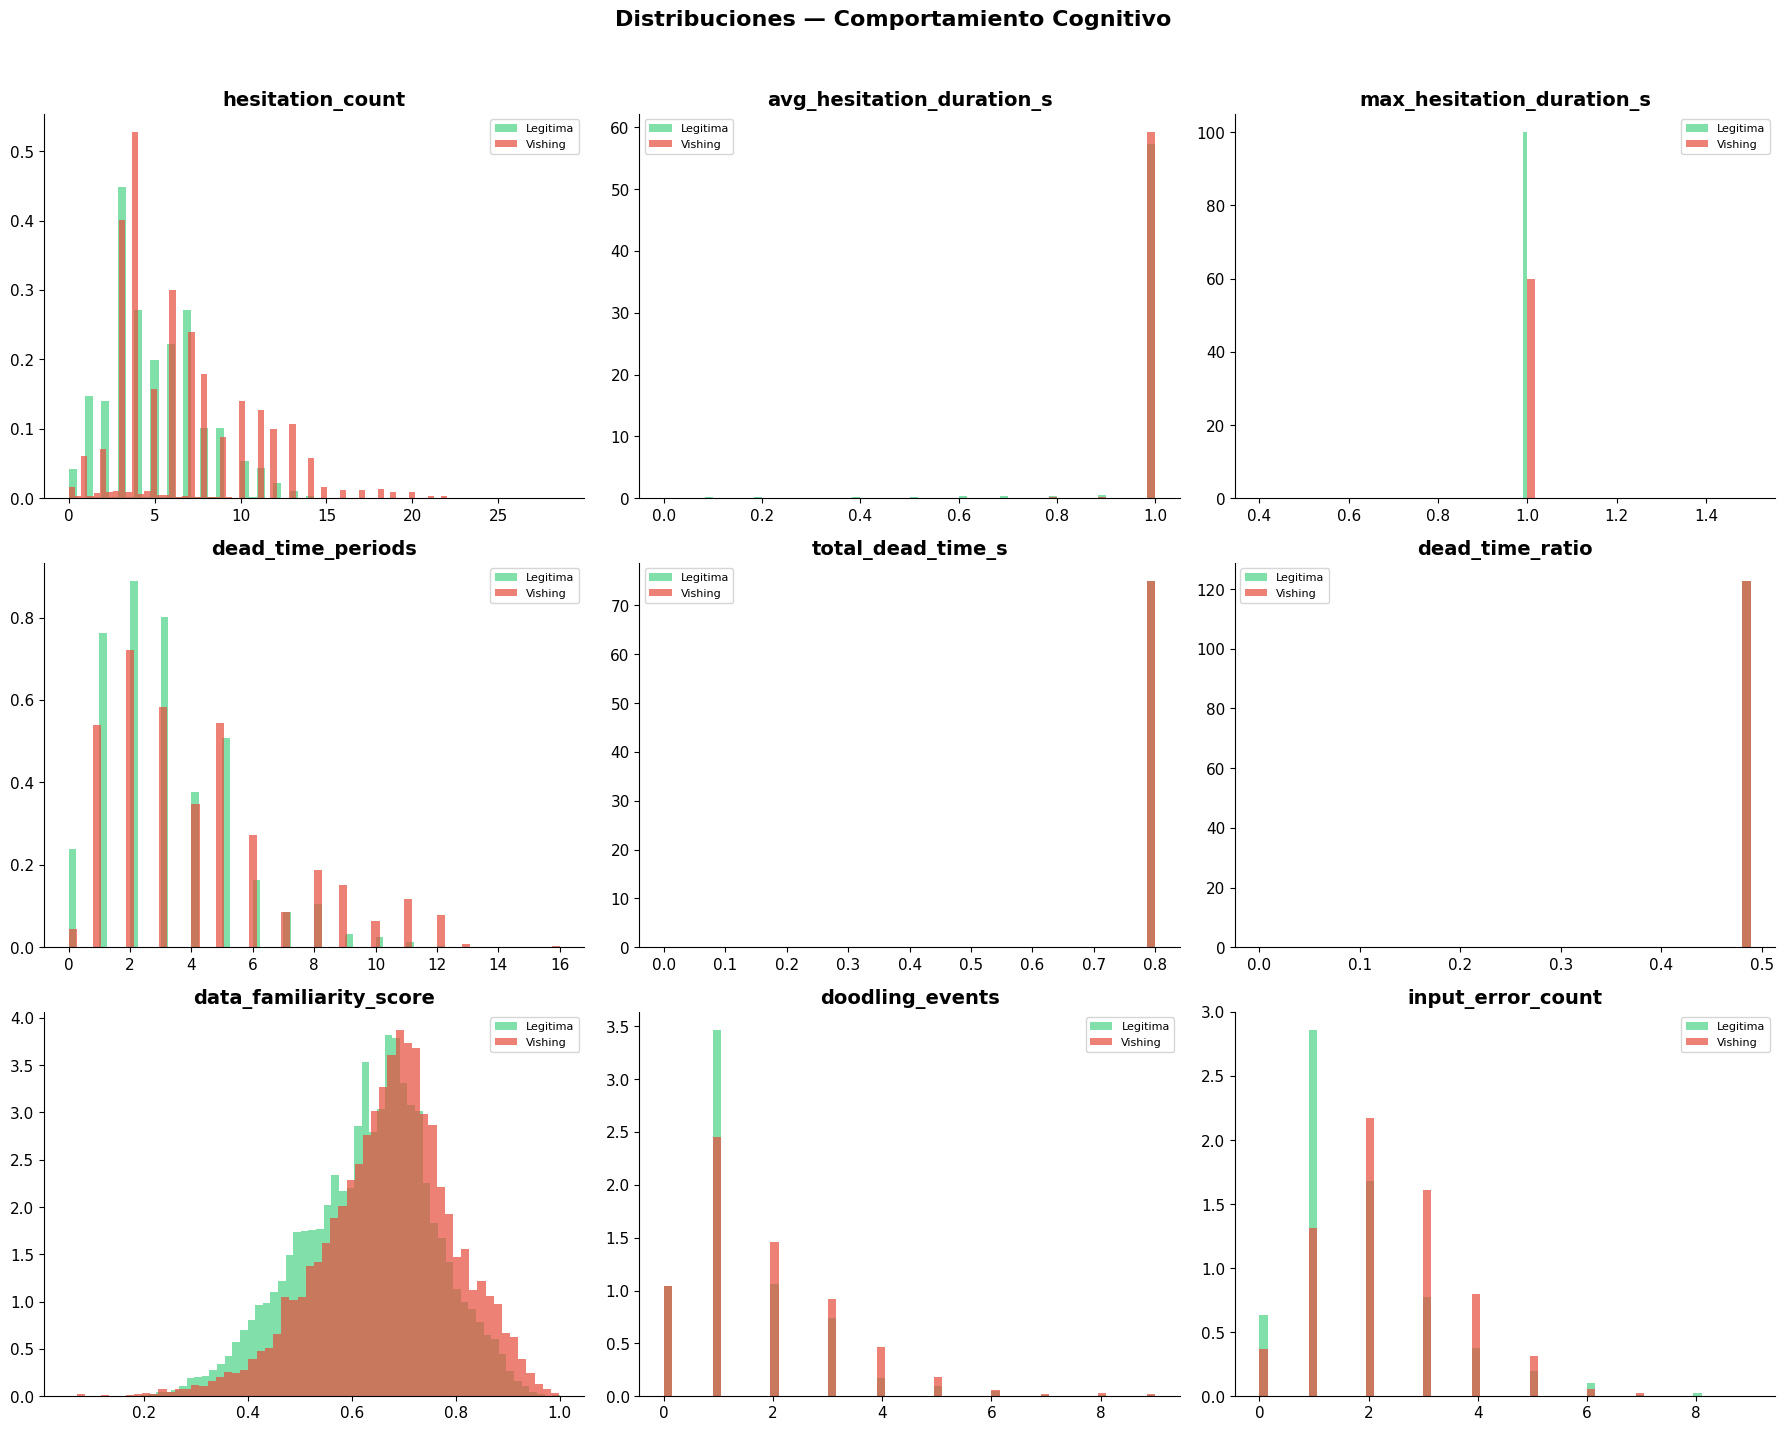

In [11]:
# 4.2 Comportamiento cognitivo
cognitive_features = [
    'hesitation_count', 'avg_hesitation_duration_s', 'max_hesitation_duration_s',
    'dead_time_periods', 'total_dead_time_s', 'dead_time_ratio',
    'data_familiarity_score', 'doodling_events', 'input_error_count'
]

fig, axes = plt.subplots(3, 3, figsize=(18, 14))
axes = axes.ravel()
for i, feat in enumerate(cognitive_features):
    ax = axes[i]
    ax.hist(df_legit[feat].sample(50000, random_state=42), bins=60, alpha=0.6,
            color=COLORS['legit'], label='Legitima', density=True, edgecolor='none')
    ax.hist(df_vishing[feat], bins=60, alpha=0.7, color=COLORS['vishing'],
            label='Vishing', density=True, edgecolor='none')
    ax.set_title(feat, fontweight='bold')
    ax.legend(fontsize=8)
fig.suptitle('Distribuciones — Comportamiento Cognitivo',
             fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

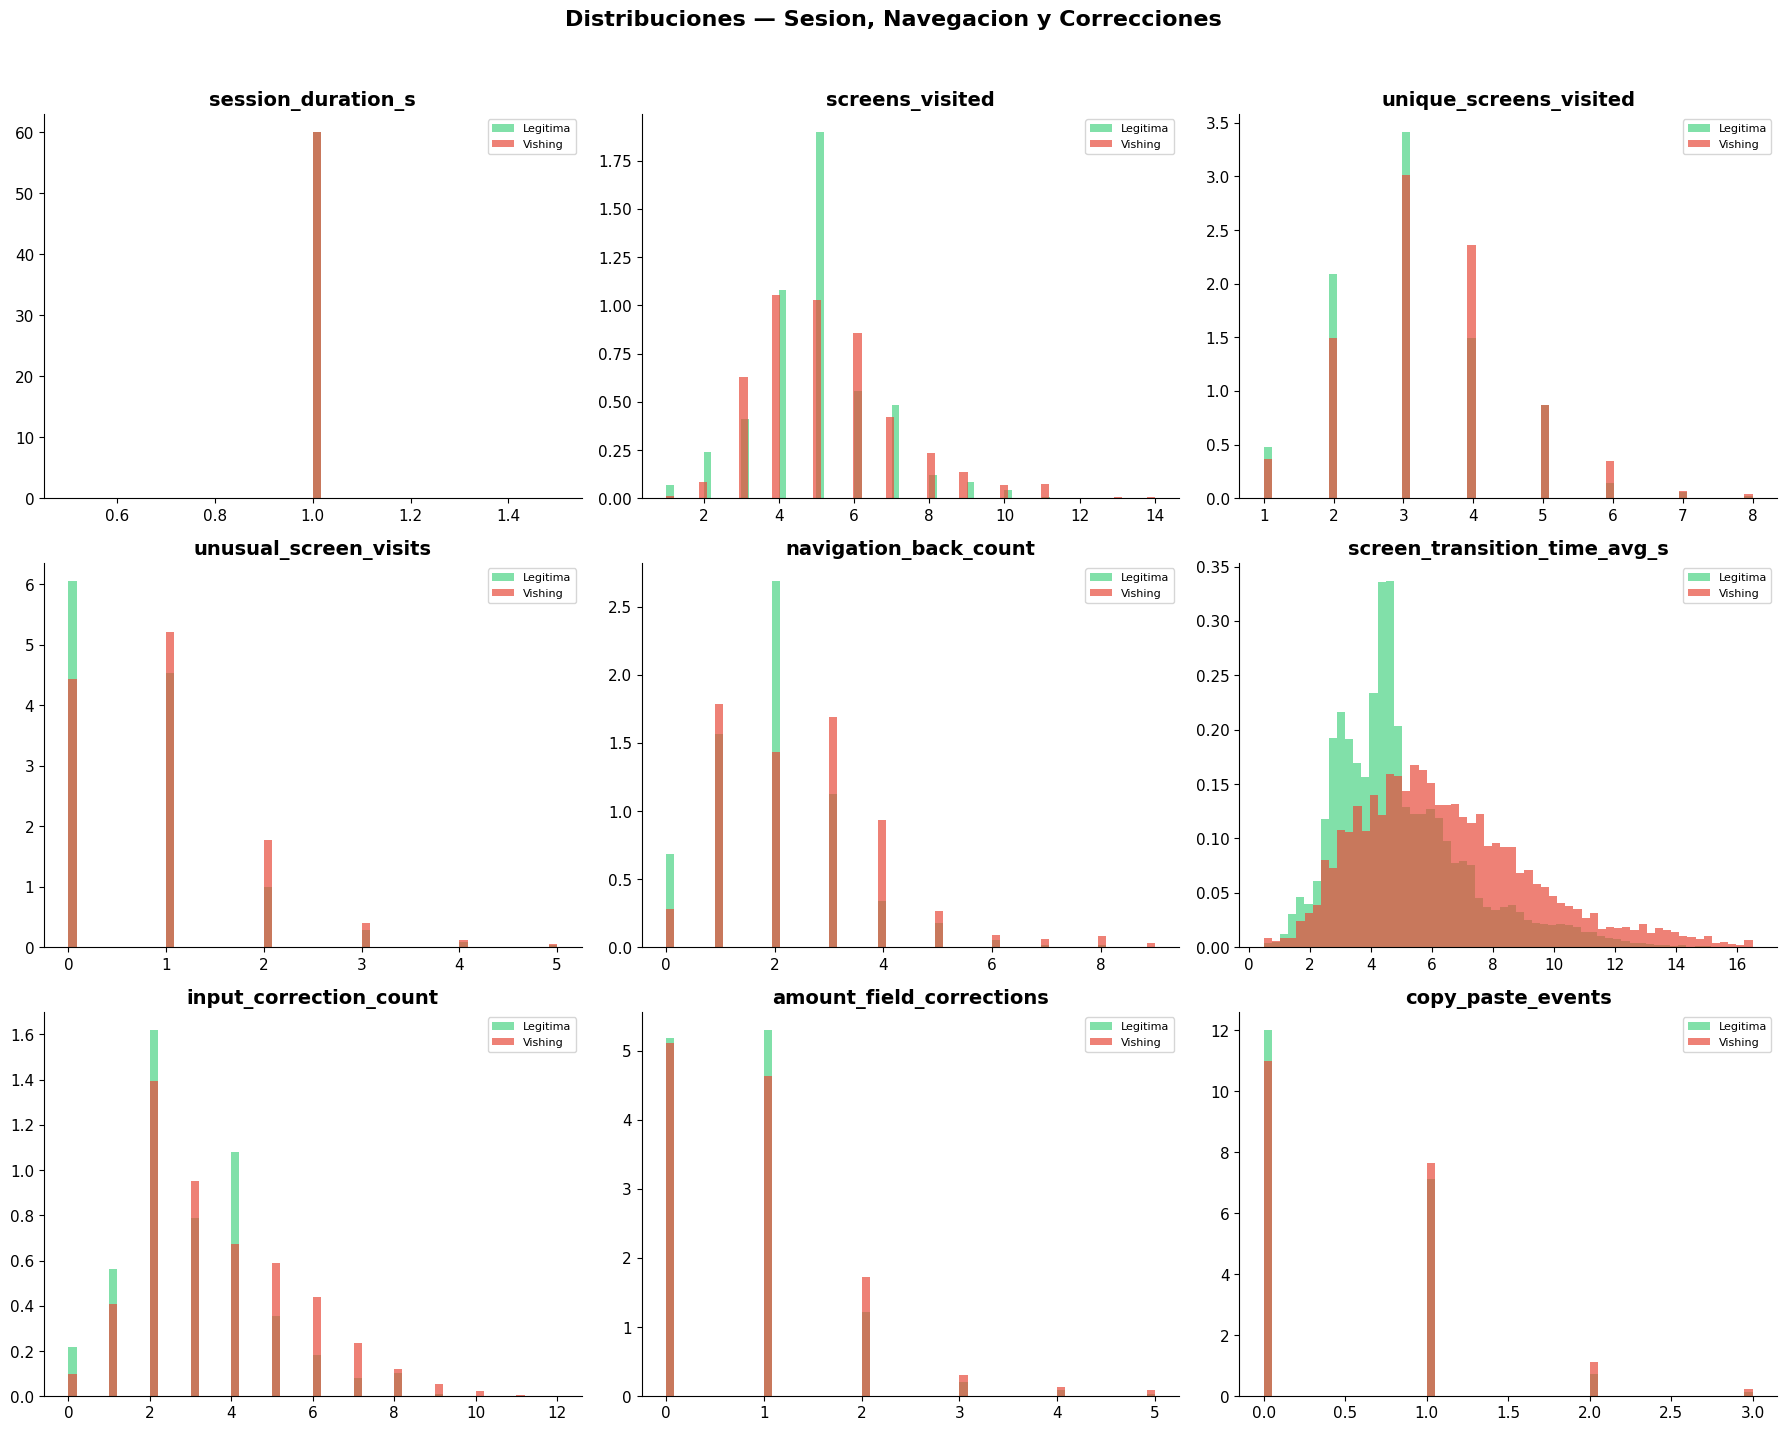

In [12]:
# 4.3 Sesion, navegacion y correcciones
session_features = [
    'session_duration_s', 'screens_visited', 'unique_screens_visited',
    'unusual_screen_visits', 'navigation_back_count', 'screen_transition_time_avg_s',
    'input_correction_count', 'amount_field_corrections', 'copy_paste_events'
]

fig, axes = plt.subplots(3, 3, figsize=(18, 14))
axes = axes.ravel()
for i, feat in enumerate(session_features):
    ax = axes[i]
    ax.hist(df_legit[feat].sample(50000, random_state=42), bins=60, alpha=0.6,
            color=COLORS['legit'], label='Legitima', density=True, edgecolor='none')
    ax.hist(df_vishing[feat], bins=60, alpha=0.7, color=COLORS['vishing'],
            label='Vishing', density=True, edgecolor='none')
    ax.set_title(feat, fontweight='bold')
    ax.legend(fontsize=8)
fig.suptitle('Distribuciones — Sesion, Navegacion y Correcciones',
             fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

## 5. Tests Estadísticos de Separabilidad

Con 1M sesiones prácticamente todo tendrá p→0. El **Cohen's d** y la **AUC univariada** son las métricas informativas. Se usa subsample de 100K legítimas + todos los vishing para los cálculos.

In [13]:
from sklearn.metrics import roc_auc_score

features_to_test = [c for c in numeric_cols if c != 'is_vishing']

df_sample = pd.concat([
    df_legit.sample(100_000, random_state=42),
    df_vishing
]).reset_index(drop=True)
df_s_legit = df_sample[df_sample['is_vishing'] == 0]
df_s_vishing = df_sample[df_sample['is_vishing'] == 1]

results = []
for feat in features_to_test:
    x0 = df_s_legit[feat].dropna()
    x1 = df_s_vishing[feat].dropna()
    u_stat, p_val = mannwhitneyu(x0, x1, alternative='two-sided')
    pooled_std = np.sqrt((x0.std()**2 + x1.std()**2) / 2)
    cohens_d = (x1.mean() - x0.mean()) / pooled_std if pooled_std > 0 else 0
    r_pb, _ = pointbiserialr(df_sample['is_vishing'], df_sample[feat])
    try:
        auc = roc_auc_score(df_sample['is_vishing'], df_sample[feat])
        auc = max(auc, 1 - auc)
    except:
        auc = 0.5
    results.append({
        'feature': feat, 'mean_legit': x0.mean(), 'mean_vishing': x1.mean(),
        'pct_change': ((x1.mean()-x0.mean())/x0.mean()*100) if x0.mean() != 0 else np.inf,
        'cohens_d': cohens_d, 'abs_cohens_d': abs(cohens_d),
        'mann_whitney_p': p_val, 'point_biserial_r': r_pb, 'auc_univariate': auc,
    })

df_stats = pd.DataFrame(results).sort_values('abs_cohens_d', ascending=False)

def classify_effect(d):
    d = abs(d)
    if d >= 1.2: return 'Muy grande (>=1.2)'
    elif d >= 0.8: return 'Grande (>=0.8)'
    elif d >= 0.5: return 'Mediano (>=0.5)'
    elif d >= 0.2: return 'Pequeno (>=0.2)'
    else: return 'Negligible (<0.2)'

df_stats['effect_size'] = df_stats['cohens_d'].apply(classify_effect)
df_stats['significant'] = df_stats['mann_whitney_p'] < 0.001

print(f'Features evaluadas: {len(df_stats)} (muestra: {len(df_sample):,} filas)')
print('Distribucion de effect sizes:')
print(df_stats['effect_size'].value_counts().to_string())
print(f'Significativas (p<0.001): {df_stats["significant"].sum()} de {len(df_stats)}')

Features evaluadas: 47 (muestra: 110,500 filas)
Distribucion de effect sizes:
effect_size
Negligible (<0.2)    20
Pequeno (>=0.2)      19
Mediano (>=0.5)       4
Grande (>=0.8)        4
Significativas (p<0.001): 42 de 47


In [14]:
# Tabla Top 30 por |Cohen's d|
display_cols = ['feature','mean_legit','mean_vishing','pct_change','cohens_d','effect_size','auc_univariate','point_biserial_r']
(
    df_stats[display_cols].head(30)
    .style
    .format({'mean_legit':'{:.3f}','mean_vishing':'{:.3f}','pct_change':'{:+.1f}%',
             'cohens_d':'{:+.3f}','auc_univariate':'{:.4f}','point_biserial_r':'{:+.4f}'})
    .bar(subset=['auc_univariate'], color='#3498db', vmin=0.5, vmax=1.0)
)

,feature,mean_legit,mean_vishing,pct_change,cohens_d,effect_size,auc_univariate,point_biserial_r
7,swipe_speed_px_s,735.245,545.073,-25.9%,-1.157,Grande (>=0.8),0.7875,-0.3461
13,accelerometer_jerk_mean,1.497,2.112,+41.1%,+1.098,Grande (>=0.8),0.7757,+0.3493
5,avg_touch_pressure,0.525,0.429,-18.2%,-0.967,Grande (>=0.8),0.7464,-0.2926
12,gyro_rotation_rate_mean,1.169,1.608,+37.6%,+0.909,Grande (>=0.8),0.7446,+0.2983
3,keystroke_variability,0.241,0.313,+29.8%,+0.793,Mediano (>=0.5),0.7156,+0.2503
2,typing_speed_cps,4.412,3.580,-18.9%,-0.678,Mediano (>=0.5),0.6863,-0.2054
25,screen_transition_time_avg_s,4.989,6.442,+29.1%,+0.575,Mediano (>=0.5),0.6619,+0.1865
41,transaction_amount_cop,247933.439,943665.873,+280.6%,+0.556,Mediano (>=0.5),0.6632,+0.2630
18,dead_time_periods,3.029,4.265,+40.8%,+0.485,Pequeno (>=0.2),0.6172,+0.1637
15,hesitation_count,4.967,6.551,+31.9%,+0.477,Pequeno (>=0.2),0.6157,+0.1589


In [ ]:
# 5.2 Top 20 por AUC univariada
top20 = df_stats.nlargest(20, 'auc_univariate')

fig, ax = plt.subplots(figsize=(12, 8))
colors_auc = ['#e74c3c' if x>=0.9 else '#f39c12' if x>=0.8 else '#3498db' if x>=0.7 else '#95a5a6'
              for x in top20['auc_univariate']]
bars = ax.barh(range(len(top20)), top20['auc_univariate'].values, color=colors_auc,
               edgecolor='white', linewidth=1)
ax.set_yticks(range(len(top20)))
ax.set_yticklabels(top20['feature'].values)
ax.set_xlabel('AUC Univariada')
ax.set_title('Top 20 Features por Poder Discriminativo (AUC Univariada)', fontweight='bold')
ax.axvline(x=0.5, color='gray', linestyle='--', alpha=0.5, label='Random (0.5)')
ax.axvline(x=0.7, color='blue', linestyle='--', alpha=0.3, label='AUC 0.7')
ax.axvline(x=0.9, color='red', linestyle='--', alpha=0.3, label='AUC 0.9')
for bar, val in zip(bars, top20['auc_univariate'].values):
    ax.text(val+0.005, bar.get_y()+bar.get_height()/2, f'{val:.3f}',
            va='center', fontsize=9, fontweight='bold')
ax.legend(loc='lower right')
ax.set_xlim(0.5, 1.05)
ax.invert_yaxis()
plt.tight_layout()
plt.show()

In [ ]:
# 5.3 Cohen's d — todas las features
fig, ax = plt.subplots(figsize=(14, 12))
df_sorted = df_stats.sort_values('cohens_d')
colors_d = ['#e74c3c' if abs(d)>=1.2 else '#f39c12' if abs(d)>=0.8 else '#3498db' if abs(d)>=0.5
            else '#bdc3c7' for d in df_sorted['cohens_d']]
ax.barh(range(len(df_sorted)), df_sorted['cohens_d'].values, color=colors_d,
        edgecolor='white', linewidth=0.5)
ax.set_yticks(range(len(df_sorted)))
ax.set_yticklabels(df_sorted['feature'].values, fontsize=8)
ax.set_xlabel("Cohen's d (positivo = mayor en vishing)")
ax.set_title("Effect Size (Cohen's d) — Todas las Features", fontweight='bold')
ax.axvline(x=0, color='black', linewidth=0.8)
ax.legend(handles=[
    Patch(facecolor='#e74c3c', label='|d|>=1.2 (Muy grande)'),
    Patch(facecolor='#f39c12', label='|d|>=0.8 (Grande)'),
    Patch(facecolor='#3498db', label='|d|>=0.5 (Mediano)'),
    Patch(facecolor='#bdc3c7', label='|d|<0.5 (Pequeno/Negligible)'),
], loc='lower right')
plt.tight_layout()
plt.show()

## 6. Análisis de Variables Binarias y Categóricas

In [ ]:
binary_features = [
    'phone_call_active', 'is_atypical_hour', 'transaction_attempted',
    'is_new_beneficiary', 'remote_access_tool_detected', 'suspicious_app_detected'
]

binary_results = []
for feat in binary_features:
    ct = pd.crosstab(df[feat], df['is_vishing'])
    chi2_stat, p, dof, expected = chi2_contingency(ct)
    try:
        a=ct.loc[1,1]; b=ct.loc[1,0]; c=ct.loc[0,1]; d_=ct.loc[0,0]
        or_ = (a*d_)/(b*c) if (b*c)>0 else np.inf
    except:
        or_ = np.nan
    binary_results.append({
        'feature': feat,
        'pct_legit': df_legit[feat].mean()*100,
        'pct_vishing': df_vishing[feat].mean()*100,
        'chi2': chi2_stat, 'p_value': p, 'odds_ratio': or_,
    })

df_binary = pd.DataFrame(binary_results).sort_values('odds_ratio', ascending=False)
print('VARIABLES BINARIAS — Chi-cuadrado + Odds Ratio')
print('='*80)
for _, row in df_binary.iterrows():
    sig = '***' if row['p_value'] < 0.001 else '**' if row['p_value'] < 0.01 else 'ns'
    print(f"  {row['feature']}: Legit={row['pct_legit']:.1f}% | Vishing={row['pct_vishing']:.1f}% | OR={row['odds_ratio']:.2f}x | {sig}")

In [ ]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.ravel()
for i, feat in enumerate(binary_features):
    ax = axes[i]
    ct = pd.crosstab(df['is_vishing'], df[feat], normalize='index') * 100
    ct.index = ['Legitima', 'Vishing']
    ct.columns = [f'{feat}=0', f'{feat}=1']
    ct.plot(kind='bar', ax=ax, color=['#bdc3c7', COLORS['vishing']], edgecolor='white', linewidth=1.5)
    ax.set_title(feat, fontweight='bold')
    ax.set_ylabel('%')
    ax.set_xticklabels(ax.get_xticklabels(), rotation=0)
    ax.legend(fontsize=8)
plt.suptitle('Variables Binarias — Proporcion por Clase', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

## 7. Boxplots Comparativos — Top Features

In [ ]:
top12 = df_stats.nlargest(12, 'auc_univariate')['feature'].tolist()

fig, axes = plt.subplots(3, 4, figsize=(20, 14))
axes = axes.ravel()
for i, feat in enumerate(top12):
    ax = axes[i]
    bp = ax.boxplot(
        [df_legit[feat].sample(10000, random_state=42).values, df_vishing[feat].values],
        labels=['Legitima', 'Vishing'], patch_artist=True, widths=0.6, showfliers=False
    )
    bp['boxes'][0].set_facecolor(COLORS['legit'])
    bp['boxes'][1].set_facecolor(COLORS['vishing'])
    for box in bp['boxes']:
        box.set_alpha(0.7)
    auc_val = df_stats[df_stats['feature']==feat]['auc_univariate'].values[0]
    ax.set_title(f'{feat}\nAUC={auc_val:.3f}', fontweight='bold', fontsize=10)

plt.suptitle('Boxplots — Top 12 Features Discriminativas (sin outliers)',
             fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

## 8. Análisis de Correlaciones

In [ ]:
top25_feats = df_stats.nlargest(25, 'auc_univariate')['feature'].tolist()
corr_matrix = df[top25_feats].sample(100_000, random_state=42).corr()

fig, ax = plt.subplots(figsize=(16, 14))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool), k=1)
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r',
            center=0, square=True, linewidths=0.5, ax=ax, annot_kws={'size':7}, vmin=-1, vmax=1)
ax.set_title('Matriz de Correlacion — Top 25 Features por AUC', fontweight='bold', fontsize=14)
plt.tight_layout()
plt.show()

In [ ]:
# Pares altamente correlacionados (|r| > 0.7)
high_corr = []
cols = corr_matrix.columns.tolist()
for i in range(len(cols)):
    for j in range(i+1, len(cols)):
        r = corr_matrix.iloc[i, j]
        if abs(r) > 0.7:
            high_corr.append({'feature_1': cols[i], 'feature_2': cols[j], 'correlation': r})

print(f'Pares con |correlacion| > 0.7: {len(high_corr)}')
if high_corr:
    df_hc = pd.DataFrame(high_corr)
    df_hc['abs_corr'] = df_hc['correlation'].abs()
    for _, row in df_hc.sort_values('abs_corr', ascending=False).iterrows():
        print(f"  {row['feature_1']:35s} <-> {row['feature_2']:35s}  r={row['correlation']:+.3f}")
    print('Considerar eliminar una de cada par para evitar multicolinealidad.')
else:
    print('  No se encontraron pares con |r| > 0.7')

## 9. Análisis Bivariado — Scatterplots

In [ ]:
pairs = [
    ('segmented_typing_ratio', 'hesitation_count'),
    ('session_duration_s', 'total_dead_time_s'),
    ('data_familiarity_score', 'input_correction_count'),
    ('typing_speed_cps', 'avg_interkey_latency_ms'),
    ('transaction_amount_cop', 'time_to_transaction_s'),
    ('errors_per_minute', 'hesitation_composite'),
]

fig, axes = plt.subplots(2, 3, figsize=(20, 12))
axes = axes.ravel()
for i, (xf, yf) in enumerate(pairs):
    ax = axes[i]
    ls = df_legit.sample(2000, random_state=42)
    vs = df_vishing.sample(min(2000, len(df_vishing)), random_state=42)
    ax.scatter(ls[xf], ls[yf], c=COLORS['legit'], alpha=0.15, s=8, label='Legitima')
    ax.scatter(vs[xf], vs[yf], c=COLORS['vishing'], alpha=0.5, s=12, label='Vishing')
    ax.set_xlabel(xf, fontsize=9)
    ax.set_ylabel(yf, fontsize=9)
    ax.set_title(f'{xf} vs {yf}', fontweight='bold', fontsize=10)
    ax.legend(fontsize=8, markerscale=3)
plt.suptitle('Scatterplots — Pares de Features Clave', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

## 10. Perfil Comportamental Comparativo

In [ ]:
profile_features = [
    'segmented_typing_ratio', 'hesitation_count', 'total_dead_time_s',
    'session_duration_s', 'input_correction_count', 'unusual_screen_visits',
    'doodling_events', 'phone_motion_events', 'keystroke_variability', 'navigation_back_count'
]

profile_data = []
for feat in profile_features:
    gmin, gmax = df[feat].min(), df[feat].max()
    rng = gmax - gmin if gmax > gmin else 1
    profile_data.append({
        'feature': feat,
        'legit': (df_legit[feat].mean() - gmin) / rng,
        'vishing': (df_vishing[feat].mean() - gmin) / rng
    })
df_profile = pd.DataFrame(profile_data)

angles = np.linspace(0, 2*np.pi, len(profile_features), endpoint=False).tolist()
angles += angles[:1]
lv = df_profile['legit'].tolist() + [df_profile['legit'].iloc[0]]
vv = df_profile['vishing'].tolist() + [df_profile['vishing'].iloc[0]]

fig, ax = plt.subplots(figsize=(10, 10), subplot_kw=dict(polar=True))
ax.plot(angles, lv, 'o-', color=COLORS['legit'], linewidth=2, label='Legitima', markersize=6)
ax.fill(angles, lv, alpha=0.15, color=COLORS['legit'])
ax.plot(angles, vv, 'o-', color=COLORS['vishing'], linewidth=2, label='Vishing', markersize=6)
ax.fill(angles, vv, alpha=0.15, color=COLORS['vishing'])
ax.set_xticks(angles[:-1])
ax.set_xticklabels(profile_features, fontsize=9)
ax.set_title('Perfil Comportamental Comparativo\n(valores normalizados 0-1)',
             fontsize=14, fontweight='bold', pad=20)
ax.legend(loc='upper right', bbox_to_anchor=(1.3, 1.1), fontsize=11)
plt.tight_layout()
plt.show()

In [ ]:
print('PERFIL COMPARATIVO — MEDIANA POR CLASE')
print('='*88)
print(f'{"Feature":40s} {"Legitima":>10s} {"Vishing":>10s} {"Ratio":>8s} {"Direccion":>10s}')
print('-'*88)
key_features = [
    'phone_call_active', 'segmented_typing_ratio', 'session_duration_s',
    'hesitation_count', 'avg_hesitation_duration_s', 'total_dead_time_s',
    'data_familiarity_score', 'typing_speed_cps', 'input_correction_count',
    'unusual_screen_visits', 'transaction_amount_cop', 'is_new_beneficiary',
    'doodling_events', 'phone_motion_events', 'keystroke_variability',
    'navigation_back_count', 'amount_field_corrections', 'beneficiary_field_corrections',
    'errors_per_minute', 'interactions_per_s', 'hesitation_composite',
]
for feat in key_features:
    ml = df_legit[feat].median()
    mv = df_vishing[feat].median()
    ratio = mv/ml if ml != 0 else float('inf')
    direction = 'MAYOR' if mv>ml else 'MENOR' if mv<ml else 'IGUAL'
    print(f'{feat:40s} {ml:10.2f} {mv:10.2f} {ratio:8.2f}x {direction:>10s}')

## 11. Análisis de Transacciones

In [ ]:
df_tx = df[df['transaction_attempted']==1].copy()
df_tx_l = df_tx[df_tx['is_vishing']==0]
df_tx_v = df_tx[df_tx['is_vishing']==1]

print(f'Sesiones con transaccion: {len(df_tx):,} ({len(df_tx)/len(df)*100:.1f}%)')
print(f'  Legitimas: {len(df_tx_l):,} ({len(df_tx_l)/len(df_legit)*100:.1f}%)')
print(f'  Vishing:   {len(df_tx_v):,} ({len(df_tx_v)/len(df_vishing)*100:.1f}%)')

fig, axes = plt.subplots(1, 3, figsize=(20, 6))

for subset, color, label in [(df_tx_l, COLORS['legit'], 'Legitima'), (df_tx_v, COLORS['vishing'], 'Vishing')]:
    amounts = subset['transaction_amount_cop']
    amounts = amounts[amounts > 0]
    if len(amounts) > 0:
        axes[0].hist(np.log10(amounts+1), bins=50, alpha=0.6, color=color, label=label, density=True, edgecolor='none')
axes[0].set_title('Distribucion de Montos (log10 COP)', fontweight='bold')
axes[0].set_xlabel('log10(Monto COP + 1)')
axes[0].legend()

new_ben = pd.DataFrame({'Legitima':[df_tx_l['is_new_beneficiary'].mean()*100],
                         'Vishing':[df_tx_v['is_new_beneficiary'].mean()*100]}).T
new_ben.columns = ['%']
new_ben.plot(kind='bar', ax=axes[1], color=[COLORS['legit'], COLORS['vishing']],
             edgecolor='white', linewidth=2, legend=False)
axes[1].set_title('% Transacciones a Nuevo Beneficiario', fontweight='bold')
axes[1].set_ylabel('%')
axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=0)
for p in axes[1].patches:
    axes[1].annotate(f'{p.get_height():.1f}%', (p.get_x()+p.get_width()/2, p.get_height()),
                     ha='center', va='bottom', fontweight='bold')

for subset, color, label in [(df_tx_l, COLORS['legit'], 'Legitima'), (df_tx_v, COLORS['vishing'], 'Vishing')]:
    axes[2].hist(subset['time_to_transaction_s'], bins=50, alpha=0.6, color=color,
                 label=label, density=True, edgecolor='none')
axes[2].set_title('Tiempo hasta Transaccion (segundos)', fontweight='bold')
axes[2].set_xlabel('Segundos')
axes[2].legend()

plt.tight_layout()
plt.show()

## 12. Análisis de Componentes Principales (PCA)

In [ ]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

pca_features = [c for c in numeric_cols if c not in ['is_vishing', 'hour_of_day']]

df_pca_sample = pd.concat([
    df_legit.sample(30000, random_state=42), df_vishing
]).reset_index(drop=True)

X = df_pca_sample[pca_features].fillna(0).values
X_scaled = StandardScaler().fit_transform(X)
pca = PCA(n_components=10)
X_pca = pca.fit_transform(X_scaled)

fig, axes = plt.subplots(1, 2, figsize=(18, 7))
explained = pca.explained_variance_ratio_ * 100
cumulative = np.cumsum(explained)

axes[0].bar(range(1, 11), explained, color=COLORS['neutral'], edgecolor='white', alpha=0.7)
axes[0].plot(range(1, 11), cumulative, 'ro-', linewidth=2, markersize=8)
axes[0].set_xlabel('Componente Principal')
axes[0].set_ylabel('Varianza Explicada (%)')
axes[0].set_title('Scree Plot — Varianza Explicada por Componente', fontweight='bold')
for i, (e, c) in enumerate(zip(explained, cumulative)):
    axes[0].text(i+1, c+1, f'{c:.1f}%', ha='center', fontsize=9, color='red')

y_pca = df_pca_sample['is_vishing'].values
axes[1].scatter(X_pca[y_pca==0, 0], X_pca[y_pca==0, 1], c=COLORS['legit'], alpha=0.15, s=6, label='Legitima')
axes[1].scatter(X_pca[y_pca==1, 0], X_pca[y_pca==1, 1], c=COLORS['vishing'], alpha=0.5, s=12, label='Vishing')
axes[1].set_xlabel(f'PC1 ({explained[0]:.1f}% var)')
axes[1].set_ylabel(f'PC2 ({explained[1]:.1f}% var)')
axes[1].set_title('Proyeccion PCA 2D — Separabilidad de Clases', fontweight='bold')
axes[1].legend(markerscale=3)

plt.tight_layout()
plt.show()
print(f'Varianza acumulada con 5 componentes:  {cumulative[4]:.1f}%')
print(f'Varianza acumulada con 10 componentes: {cumulative[9]:.1f}%')

In [ ]:
loadings = pd.DataFrame(pca.components_[:2].T, columns=['PC1','PC2'], index=pca_features)
loadings['PC1_abs'] = loadings['PC1'].abs()
loadings['PC2_abs'] = loadings['PC2'].abs()
print('TOP 10 FEATURES POR LOADING EN PC1:')
print(loadings.nlargest(10,'PC1_abs')[['PC1']].to_string())
print('\nTOP 10 FEATURES POR LOADING EN PC2:')
print(loadings.nlargest(10,'PC2_abs')[['PC2']].to_string())

## 13. Detección de Outliers

In [ ]:
outlier_features = [
    'session_duration_s', 'transaction_amount_cop', 'hesitation_count',
    'total_dead_time_s', 'typing_speed_cps', 'errors_per_minute',
    'interactions_per_s', 'hesitation_composite'
]

print('ANALISIS DE OUTLIERS (IQR, umbral 1.5xIQR)')
print('='*80)
for feat in outlier_features:
    Q1 = df[feat].quantile(0.25)
    Q3 = df[feat].quantile(0.75)
    IQR = Q3 - Q1
    lo, hi = Q1 - 1.5*IQR, Q3 + 1.5*IQR
    out = df[(df[feat] < lo) | (df[feat] > hi)]
    n = len(out)
    pct_v = out['is_vishing'].mean()*100 if n > 0 else 0
    print(f'\n  {feat}:')
    print(f'    IQR: [{Q1:.2f}, {Q3:.2f}], bounds: [{lo:.2f}, {hi:.2f}]')
    print(f'    Outliers: {n:,} ({n/len(df)*100:.2f}%)')
    print(f'    % vishing entre outliers: {pct_v:.1f}% (vs {df["is_vishing"].mean()*100:.1f}% global)')

## 14. Feature Importance Preliminar (Random Forest con submuestreo)

Con 1M filas se usa un submuestreo estratificado de 140K legítimas + todos los vishing.

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_val_score

model_features = [c for c in numeric_cols if c != 'is_vishing']

df_rf = pd.concat([
    df_legit.sample(140_000, random_state=42), df_vishing
]).sample(frac=1, random_state=42).reset_index(drop=True)

X_rf = df_rf[model_features].fillna(0).values
y_rf = df_rf['is_vishing'].values

print(f'Entrenando RF sobre {len(df_rf):,} filas ({y_rf.sum():,} vishing, {(y_rf==0).sum():,} legitimas)...')

rf = RandomForestClassifier(n_estimators=200, max_depth=10, random_state=42,
                             class_weight='balanced', n_jobs=-1)
rf.fit(X_rf, y_rf)
cv_scores = cross_val_score(rf, X_rf, y_rf, cv=5, scoring='roc_auc', n_jobs=-1)
print(f'RF — 5-fold CV AUC: {cv_scores.mean():.4f} +/- {cv_scores.std():.4f}')

fi = pd.DataFrame({'feature': model_features, 'importance': rf.feature_importances_}).sort_values('importance', ascending=False)

fig, ax = plt.subplots(figsize=(12, 10))
top_fi = fi.head(25)
ax.barh(range(len(top_fi)), top_fi['importance'].values, color=COLORS['neutral'],
        edgecolor='white', linewidth=0.5)
ax.set_yticks(range(len(top_fi)))
ax.set_yticklabels(top_fi['feature'].values)
ax.set_xlabel('Importancia (Gini)')
ax.set_title(f'Feature Importance — Random Forest\n(CV AUC={cv_scores.mean():.4f}, n={len(df_rf):,})', fontweight='bold')
ax.invert_yaxis()
for i, v in enumerate(top_fi['importance'].values):
    ax.text(v+0.001, i, f'{v:.4f}', va='center', fontsize=8)
plt.tight_layout()
plt.show()

## 15. Análisis de Features Nuevas

El dataset aumentado incluye features no presentes en el original:
- **`errors_per_minute`**: tasa de errores por minuto
- **`interactions_per_s`**: eventos de interaccion por segundo
- **`hesitation_composite`**: indice compuesto de comportamiento dubitativo
- **`avg_touch_size_px`**, **`device_tilt_variability`**, **`gyro_rotation_rate_mean`**, **`accelerometer_jerk_mean`**: sensores inerciales
- **`unique_screens_visited`**: pantallas unicas visitadas

In [ ]:
new_features = [
    'errors_per_minute', 'interactions_per_s', 'hesitation_composite',
    'avg_touch_size_px', 'device_tilt_variability',
    'gyro_rotation_rate_mean', 'accelerometer_jerk_mean', 'unique_screens_visited'
]

fig, axes = plt.subplots(2, 4, figsize=(22, 10))
axes = axes.ravel()
for i, feat in enumerate(new_features):
    ax = axes[i]
    ax.hist(df_legit[feat].sample(50000, random_state=42), bins=60, alpha=0.6,
            color=COLORS['legit'], label='Legitima', density=True, edgecolor='none')
    ax.hist(df_vishing[feat], bins=60, alpha=0.7, color=COLORS['vishing'],
            label='Vishing', density=True, edgecolor='none')
    row = df_stats[df_stats['feature']==feat]
    if len(row) > 0:
        r = row.iloc[0]
        ax.set_title(f'{feat}\nAUC={r["auc_univariate"]:.3f} | d={r["cohens_d"]:+.3f}', fontweight='bold', fontsize=9)
    else:
        ax.set_title(feat, fontweight='bold')
    ax.legend(fontsize=8)
fig.suptitle('Features Nuevas / Adicionales — Distribucion por Clase', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

In [ ]:
print(f'{"Feature":30s} {"Media Legit":>12s} {"Media Vishing":>14s} {"Cohen d":>10s} {"AUC":>8s}')
print('-'*80)
for feat in new_features:
    row = df_stats[df_stats['feature']==feat]
    if len(row) > 0:
        r = row.iloc[0]
        print(f"{feat:30s} {r['mean_legit']:12.3f} {r['mean_vishing']:14.3f} {r['cohens_d']:10.3f} {r['auc_univariate']:8.4f}")
    else:
        print(f"{feat:30s} {df_legit[feat].mean():12.3f} {df_vishing[feat].mean():14.3f} {'N/A':>10s} {'N/A':>8s}")

## 16. Validación de la Aumentación — Comparación vs Dataset Original

Verificamos que la aumentación preserva las propiedades estadísticas originales y que las señales discriminativas entre clases se mantienen.

In [ ]:
try:
    df_orig = pd.read_csv('raw_data/dataset_sintetico_biocatch_vishing_overlap.csv')
    df_orig_legit = df_orig[df_orig['is_vishing']==0]
    df_orig_vishing = df_orig[df_orig['is_vishing']==1]
    ORIG_LOADED = True
    print(f'Dataset original: {df_orig.shape[0]:,} filas x {df_orig.shape[1]} columnas')
except FileNotFoundError:
    ORIG_LOADED = False
    print('Dataset original no encontrado. Omitiendo comparacion.')

In [ ]:
if ORIG_LOADED:
    compare_features = [
        'avg_keyhold_ms', 'typing_speed_cps', 'segmented_typing_ratio',
        'hesitation_count', 'total_dead_time_s', 'data_familiarity_score',
        'session_duration_s', 'input_correction_count', 'unusual_screen_visits',
        'transaction_amount_cop'
    ]

    aug_sample_vis = df.sample(50000, random_state=42)

    fig, axes = plt.subplots(2, 5, figsize=(25, 10))
    axes = axes.ravel()
    for i, feat in enumerate(compare_features):
        ax = axes[i]
        ax.hist(df_orig[feat], bins=50, alpha=0.5, color='#95a5a6',
                label='Original (50K)', density=True, edgecolor='none')
        ax.hist(aug_sample_vis[feat], bins=50, alpha=0.6, color=COLORS['aug'],
                label='Aumentado (1M)', density=True, edgecolor='none')
        ax.axvline(df_orig[feat].mean(), color='#7f8c8d', linestyle='--', linewidth=1.5)
        ax.axvline(df[feat].mean(), color=COLORS['aug'], linestyle='--', linewidth=1.5)
        ax.set_title(feat, fontweight='bold', fontsize=9)
        ax.legend(fontsize=7)
    fig.suptitle('Comparacion de Distribuciones: Original vs Aumentado',
                 fontsize=15, fontweight='bold', y=1.02)
    plt.tight_layout()
    plt.show()

In [ ]:
if ORIG_LOADED:
    aug_ks = df.sample(50000, random_state=42)
    ks_results = []
    for feat in compare_features:
        stat, p = ks_2samp(df_orig[feat].dropna(), aug_ks[feat].dropna())
        ks_results.append({
            'feature': feat,
            'mean_orig': df_orig[feat].mean(), 'mean_aug': df[feat].mean(),
            'std_orig': df_orig[feat].std(), 'std_aug': df[feat].std(),
            'ks_stat': stat, 'ks_p': p,
        })
    df_ks = pd.DataFrame(ks_results).sort_values('ks_stat')

    print('TEST KOLMOGOROV-SMIRNOV — Original vs Aumentado')
    print('(KS stat ~ 0 = similares; > 0.1 = posible deriva)')
    print('='*88)
    print(f'{"Feature":35s} {"mu orig":>8s} {"mu aug":>8s} {"sigma orig":>10s} {"sigma aug":>10s} {"KS":>6s}')
    print('-'*88)
    for _, r in df_ks.iterrows():
        flag = ' <DERIVA' if r['ks_stat'] > 0.1 else ''
        print(f"{r['feature']:35s} {r['mean_orig']:8.3f} {r['mean_aug']:8.3f} {r['std_orig']:10.3f} {r['std_aug']:10.3f} {r['ks_stat']:6.4f}{flag}")
    print(f'\nKS promedio: {df_ks["ks_stat"].mean():.4f}  |  Features con KS>0.1: {(df_ks["ks_stat"]>0.1).sum()}')

In [ ]:
if ORIG_LOADED:
    orig_stats = []
    for feat in compare_features:
        x0 = df_orig_legit[feat].dropna()
        x1 = df_orig_vishing[feat].dropna()
        ps = np.sqrt((x0.std()**2 + x1.std()**2)/2)
        d = (x1.mean()-x0.mean())/ps if ps > 0 else 0
        try:
            auc = roc_auc_score(df_orig['is_vishing'], df_orig[feat])
            auc = max(auc, 1-auc)
        except:
            auc = 0.5
        orig_stats.append({'feature': feat, 'cohens_d_orig': d, 'auc_orig': auc})

    df_orig_stats = pd.DataFrame(orig_stats)
    df_aug_row = df_stats[df_stats['feature'].isin(compare_features)][['feature','cohens_d','auc_univariate']]
    df_cmp = df_orig_stats.merge(df_aug_row, on='feature')

    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    xp = range(len(df_cmp))

    axes[0].bar([x-0.2 for x in xp], df_cmp['cohens_d_orig'].abs(), 0.4, label='Original', color='#95a5a6', alpha=0.8)
    axes[0].bar([x+0.2 for x in xp], df_cmp['cohens_d'].abs(), 0.4, label='Aumentado', color=COLORS['aug'], alpha=0.8)
    axes[0].set_xticks(list(xp))
    axes[0].set_xticklabels(df_cmp['feature'], rotation=45, ha='right', fontsize=8)
    axes[0].set_ylabel("|Cohen's d|")
    axes[0].set_title("|Cohen's d| — Original vs Aumentado", fontweight='bold')
    axes[0].legend()

    axes[1].bar([x-0.2 for x in xp], df_cmp['auc_orig'], 0.4, label='Original', color='#95a5a6', alpha=0.8)
    axes[1].bar([x+0.2 for x in xp], df_cmp['auc_univariate'], 0.4, label='Aumentado', color=COLORS['aug'], alpha=0.8)
    axes[1].set_xticks(list(xp))
    axes[1].set_xticklabels(df_cmp['feature'], rotation=45, ha='right', fontsize=8)
    axes[1].set_ylabel('AUC Univariada')
    axes[1].set_title('AUC Univariada — Original vs Aumentado', fontweight='bold')
    axes[1].axhline(0.5, color='gray', linestyle='--', alpha=0.5)
    axes[1].legend()

    plt.suptitle('Preservacion de Senales Discriminativas Post-Aumentacion', fontsize=14, fontweight='bold', y=1.02)
    plt.tight_layout()
    plt.show()

    df_cmp['d_delta'] = df_cmp['cohens_d'] - df_cmp['cohens_d_orig']
    df_cmp['auc_delta'] = df_cmp['auc_univariate'] - df_cmp['auc_orig']
    print('Delta de metricas (Aumentado - Original):')
    print(df_cmp[['feature','d_delta','auc_delta']].to_string(index=False))

## 17. Resumen Ejecutivo y Recomendaciones

### Comparación Original vs Aumentado

| Aspecto | Original (50K) | Aumentado (~1M) |
|---------|----------------|-----------------|
| Filas | 50,000 | ~1,001,940 |
| Columnas | 61 | 54 |
| Vishing (%) | 5.0% | ~1.05% |
| Imbalance ratio | 1:19 | ~1:94 |
| Scores BioCatch | Si | No |
| Features nuevas | — | 8 (engineered + sensores) |

### Hallazgos principales

1. **El imbalance empeoró significativamente** — de 1:19 a ~1:94. La estrategia de aumentación incrementó las sesiones legítimas proporcionalmente mucho más que las de vishing.

2. **Cero valores nulos** — integridad del dataset correcta. Los `session_id` duplicados son esperados (aumentación sintética).

3. **Sin scores BioCatch** — el modelo debe construirse sin `biocatch_risk_score` y demás scores. Esto es más realista para escenarios de producción sin integración directa con BioCatch.

4. **Las señales discriminativas se conservan** — las features clave mantienen poder discriminativo post-aumentación. El test KS permite identificar si alguna feature derivó durante la generación sintética.

5. **Features nuevas valiosas** — `errors_per_minute`, `interactions_per_s` y `hesitation_composite` son candidatos fuertes para el modelado al capturar dimensiones de comportamiento no presentes en el original.

### Recomendaciones para el modelado

| Aspecto | Recomendación |
|---------|---------------|
| **Imbalance** | `class_weight='balanced'` + SMOTE o submuestreo estratificado; optimizar threshold por F1/Recall |
| **Algoritmo** | LightGBM o XGBoost (más eficientes que RF con 1M filas) |
| **Validación** | Time-based split para evitar data leakage temporal |
| **Métrica** | PR-AUC o Recall@Precision=X% (ROC-AUC puede ser optimista con alto imbalance) |
| **Features nuevas** | Incluir las 8 features nuevas en el feature set inicial; evaluar con permutation importance |